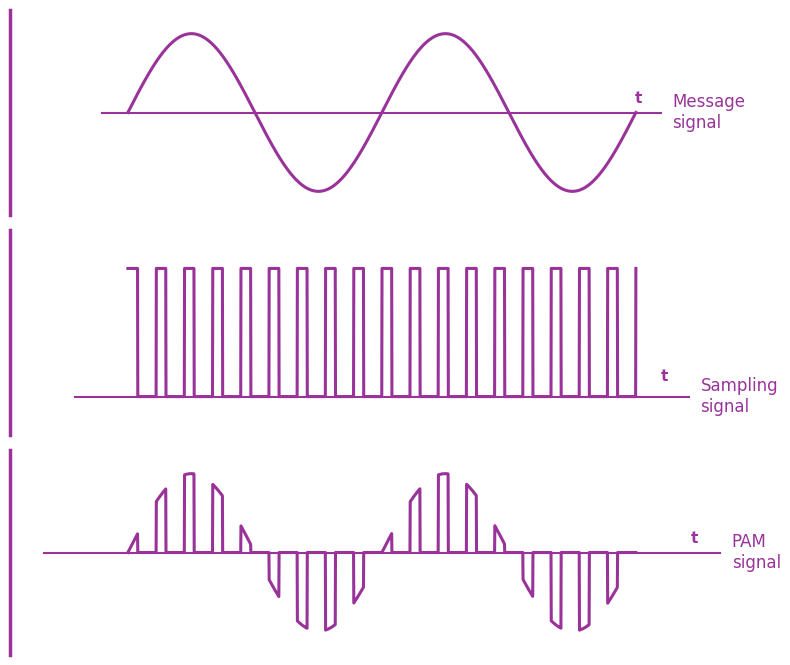

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import square

# --- Set Global Styling to Match the Image ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['lines.linewidth'] = 2.2

# 1. Coordinate and Signal Parameters
time_end = 0.1
fs = 20000  # High sampling rate for sharp pulse transitions
t = np.linspace(0, time_end, int(fs * time_end))

f_message = 20        # Message frequency (2 full cycles over 0.1s)
f_sampling = 180      # High-frequency pulse train carrier

# 2. Waveform Calculation
# Message Signal: Sinusoid crossing 0 at start
message_signal = np.sin(2 * np.pi * f_message * t)

# Sampling Signal: Unipolar pulse train transitioning between 0 and 1
sampling_signal = (square(2 * np.pi * f_sampling * t, duty=0.35) + 1) / 2

# PAM Signal: Bipolar Natural Sampling
# Multiplies the continuous wave by the switching gating train
pam_signal = message_signal * sampling_signal

# 3. Custom Function to Handle the Diagram Theme
def apply_diagram_theme(ax, label_text):
    # Hide top, right, and bottom default axes lines
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)

    # Style the left boundary line to mimic the heavy vertical axis line
    ax.spines['left'].set_color('#993399')
    ax.spines['left'].set_linewidth(2.5)

    # Strip computer-generated grid metrics and ticks
    ax.set_xticks([])
    ax.set_yticks([])

    xlim = ax.get_xlim()

    # Draw a custom horizontal baseline across the zero level
    ax.plot([xlim[0], xlim[1]], [0, 0], color='#993399', linewidth=1.5)

    # Add the 't' symbol near the right boundary tip
    ax.text(xlim[1] * 0.95, 0.12, 't', color='#993399', fontsize=11, fontweight='bold')

    # Add the descriptive string labels precisely aligned to the right edge
    ax.text(xlim[1] * 1.02, 0, label_text, color='#993399', fontsize=12,
            ha='left', va='center', multialignment='left')

# 4. Generate the Layout Canvas
fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)

# Image Purple Color Profile
purple_color = '#993399'

# --- Subplot 1: Message Signal ---
axes[0].plot(t, message_signal, color=purple_color)
apply_diagram_theme(axes[0], 'Message\nsignal')
axes[0].set_ylim([-1.3, 1.3])

# --- Subplot 2: Sampling Signal ---
axes[1].plot(t, sampling_signal, color=purple_color)
apply_diagram_theme(axes[1], 'Sampling\nsignal')
axes[1].set_ylim([-0.3, 1.3])

# --- Subplot 3: PAM Signal ---
axes[2].plot(t, pam_signal, color=purple_color)
apply_diagram_theme(axes[2], 'PAM\nsignal')
axes[2].set_ylim([-1.3, 1.3])

# Adjust margins and configuration padding
plt.tight_layout(rect=[0.05, 0.05, 0.85, 0.95])
plt.show()